<a href="https://colab.research.google.com/github/ssmahadevcse2025/DesignAnalysisOfAlgorithm/blob/main/daae2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Execution Time Comparison (Microseconds)
--------------------------------------------------
Size: 1000     Binary: 11.17 μs   Interpolation: 4.53 μs
Size: 5000     Binary: 4.11 μs   Interpolation: 2.33 μs
Size: 10000    Binary: 2.98 μs   Interpolation: 2.12 μs
Size: 50000    Binary: 3.51 μs   Interpolation: 4.67 μs
Size: 100000   Binary: 13.20 μs   Interpolation: 7.28 μs


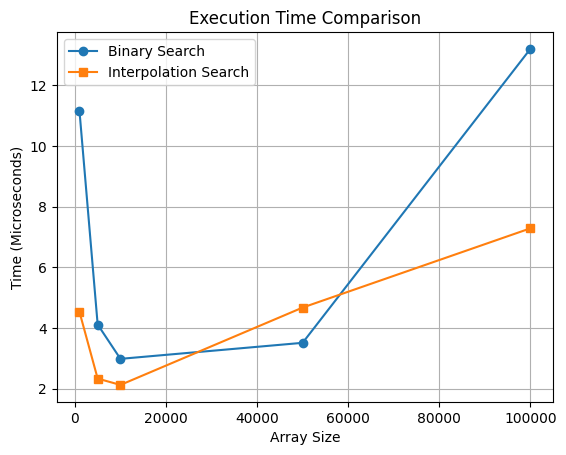

In [5]:
import time
import matplotlib.pyplot as plt

# Binary Search
def binary_search(arr, key):
    low = 0
    high = len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        if arr[mid] == key:
            return mid
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1

# Interpolation Search
def interpolation_search(arr, key):
    low = 0
    high = len(arr) - 1

    while low <= high and key >= arr[low] and key <= arr[high]:

        if low == high:
            if arr[low] == key:
                return low
            return -1

        pos = low + ((key - arr[low]) * (high - low)) // (arr[high] - arr[low])

        if arr[pos] == key:
            return pos

        if arr[pos] < key:
            low = pos + 1
        else:
            high = pos - 1

    return -1

sizes = [1000, 5000, 10000, 50000, 100000]

binary_times = []
interpolation_times = []

for size in sizes:

    arr = list(range(1, size + 1))
    key = size // 2

    start = time.perf_counter()
    binary_search(arr, key)
    end = time.perf_counter()

    binary_times.append((end - start) * 1000000)

    start = time.perf_counter()
    interpolation_search(arr, key)
    end = time.perf_counter()

    interpolation_times.append((end - start) * 1000000)

print("\nExecution Time Comparison (Microseconds)")
print("-" * 50)

for i in range(len(sizes)):
    print(f"Size: {sizes[i]:<8} Binary: {binary_times[i]:.2f} μs   Interpolation: {interpolation_times[i]:.2f} μs")

plt.plot(sizes, binary_times, marker='o', label='Binary Search')
plt.plot(sizes, interpolation_times, marker='s', label='Interpolation Search')

plt.title("Execution Time Comparison")
plt.xlabel("Array Size")
plt.ylabel("Time (Microseconds)")
plt.legend()
plt.grid(True)

plt.show()